# 🇹🇿 Tanzania Climate Data Analysis (2015–2026)

## Objective  
Analyze temperature, rainfall, and climate variability trends in Tanzania using NASA POWER dataset.

### Focus
- Data cleaning  
- Rainy vs dry season patterns  
- Temperature and humidity variations  
- Agricultural climate insights  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading

I load the NASA POWER dataset and inspect structure, columns, and basic integrity.

In [6]:
data = pd.read_csv("../Data/tanzania.csv")
print(data.head(10))
data.columns

   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  27.56    29.52    26.22       3.30         7.24  80.97  4.68   
1  2015    2  27.59    29.99    25.92       4.07         3.40  79.63  4.48   
2  2015    3  27.47    29.29    26.25       3.04         7.17  80.02  4.91   
3  2015    4  27.28    29.17    25.96       3.21        16.07  81.78  4.88   
4  2015    5  26.68    27.83    25.84       1.99        18.83  82.99  4.17   
5  2015    6  27.27    29.33    25.71       3.62         7.59  81.89  4.63   
6  2015    7  27.02    28.65    25.70       2.95         4.93  82.00  4.07   
7  2015    8  27.26    29.32    25.92       3.40         1.57  81.84  4.75   
8  2015    9  27.35    29.77    25.80       3.97         0.70  81.34  4.42   
9  2015   10  27.33    29.70    25.59       4.11         2.04  81.19  4.79   

   WS2M_MAX      PS   QV2M  
0      6.01  100.52  18.61  
1      5.28  100.52  18.31  
2      5.99  100.56  18.30  
3      6.07  100.47  18.5

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M'],
      dtype='object')

In [7]:
print(data.shape)
print(data.info())

(4108, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 385.3 KB
None


## 2. Data Cleaning

I handle missing values, convert date formats, and remove duplicates.

NASA uses -999 as missing values, which we convert to NaN.

In [8]:
data.replace(-999, np.nan, inplace=True)
print(data.isna().sum())
print(data.describe())
print(data.min())

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64
              YEAR          DOY          T2M      T2M_MAX     T2M_MIN  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.00000   
mean   2020.131451   180.121227    26.802422    29.163493    25.03813   
std       3.248907   106.294767     1.325388     1.371155     1.53544   
min    2015.000000     1.000000    22.680000    25.410000    20.03000   
25%    2017.000000    86.000000    25.670000    28.090000    23.71000   
50%    2020.000000   179.000000    26.990000    29.080000    25.37500   
75%    2023.000000   272.000000    27.900000    30.170000    26.31000   
max    2026.000000   366.000000    29.970000    33.930000    28.01000   

         T2M_RANGE  PRECTOTCORR         RH2M         WS2M     WS2M_MAX  \
count  4108.000000  4108.000000  4108.000000  4108.

## 3. Date Processing

I convert YEAR and DOY into a proper datetime column for time-series analysis.

In [14]:
data["Month"] = pd.to_datetime(data["YEAR"].astype(str) + "-" + data["DOY"].astype(str), format="%Y-%j").dt.month

monthly_temp = data.groupby("Month")["T2M"].mean()
duplicates = data.duplicated().sum()
print("Duplicates:", duplicates)
data = data.drop_duplicates()
missing = data.isna().mean() * 100
print(missing)

Duplicates: 0
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Month          0.0
dtype: float64


In [15]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(data[cols].apply(zscore))
outliers = (z_scores > 3).sum()

print(outliers)

T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64


## 4. Temperature Trends

I analyze monthly average temperature to identify seasonal patterns and warming trends.

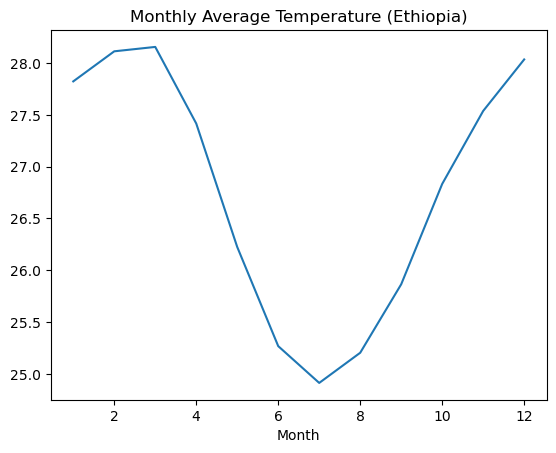

In [10]:
monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature (Ethiopia)")
plt.show()

## 5. Rainfall Patterns

I examine precipitation distribution to understand wet and dry seasons.

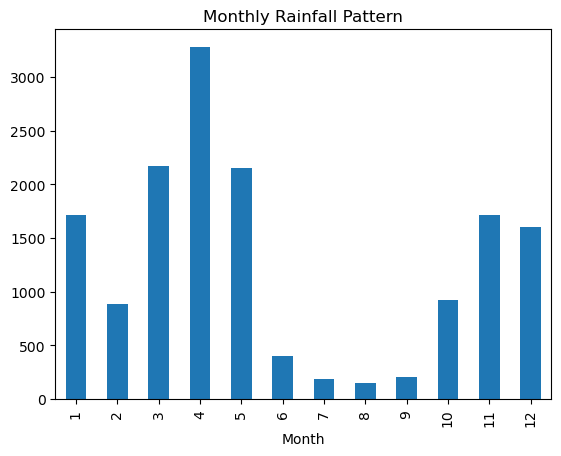

In [12]:
monthly_rain = data.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall Pattern")
plt.show()

## 6. Climate Variable Relationships

I examine correlations between temperature, rainfall, humidity, and wind.

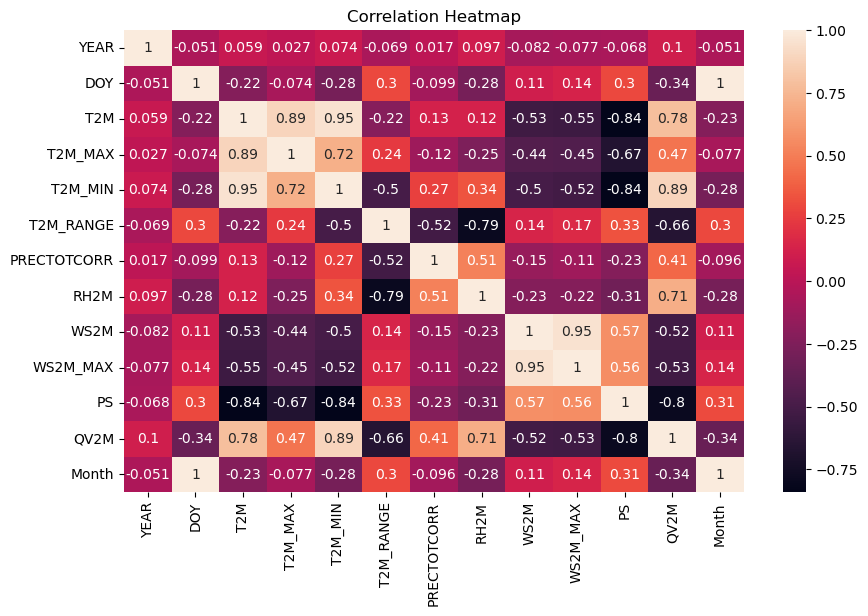

In [13]:

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()